# Exploratory Analysis, Anomaly Detection & Predictive Insights

This notebook presents the analytical core of the **Aadhaar Lifecycle Intelligence & Maturity Framework (ALIMF)**.  
Using cleaned Aadhaar enrolment, demographic update, and biometric update data, the analysis progresses from descriptive exploration to anomaly detection and short-term demand forecasting.

The objective of this notebook is to extract actionable insights that support proactive governance, operational monitoring, and informed decision-making for UIDAI.

---

## Analysis Flow

The analysis in this notebook is structured as follows:

1. **Exploratory Data Analysis (EDA)**  
   Identification of temporal, regional, and age-based patterns in Aadhaar enrolments and updates.

2. **Anomaly Detection**  
   District-level detection of abnormal biometric and demographic update spikes that may indicate operational stress or localized service surges.

3. **Predictive Indicators & Early Warning**  
   Development of simple, explainable forecasting signals to anticipate short-term Aadhaar service demand.

4. **Policy Implications & Recommendations**  
   Translation of analytical findings into actionable insights for infrastructure planning and service optimization.

This layered approach ensures that the analysis moves beyond historical reporting and contributes toward lifecycle-driven Aadhaar intelligence.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
enrolment_df = pd.read_csv("processed/enrolment_clean.csv", parse_dates=["date"])
demographic_df = pd.read_csv("processed/demographic_clean.csv", parse_dates=["date"])
biometric_df = pd.read_csv("processed/biometric_clean.csv", parse_dates=["date"])


## Univariate Analysis


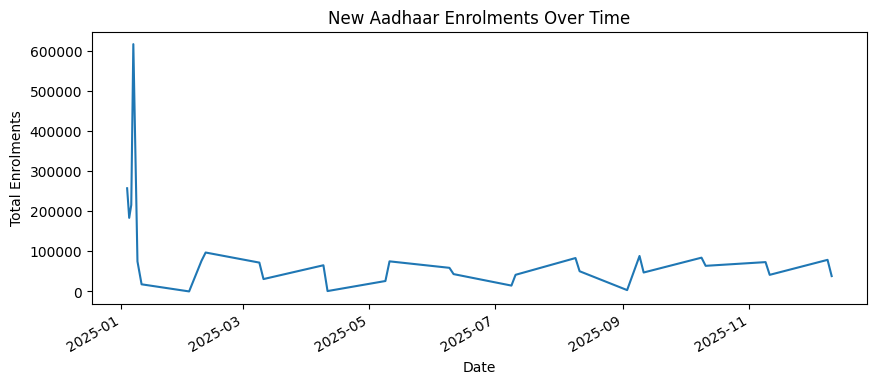

In [34]:
enrol_time = enrolment_df.groupby("date")["total_enrolments"].sum()

plt.figure(figsize=(10,4))
enrol_time.plot()
plt.title("New Aadhaar Enrolments Over Time")
plt.ylabel("Total Enrolments")
plt.xlabel("Date")
plt.savefig("assets/univariate_enrolment.png", dpi=300, bbox_inches="tight")
plt.show()


New Aadhaar enrolments show relatively low but consistent demand, indicating a mature Aadhaar ecosystem.

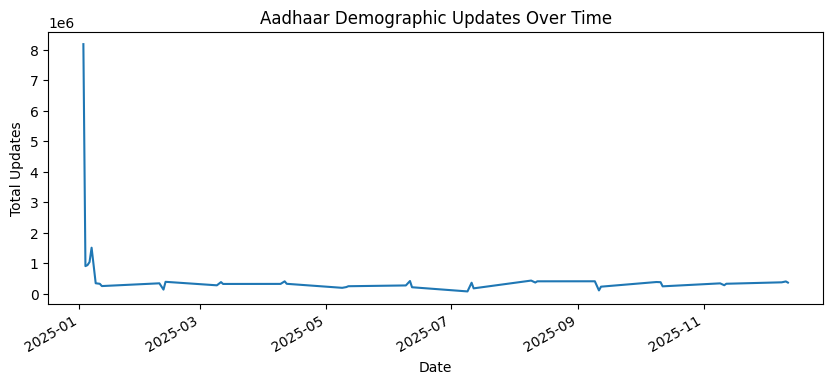

In [4]:
demo_time = demographic_df.groupby("date")["total_demographic_updates"].sum()

plt.figure(figsize=(10,4))
demo_time.plot()
plt.title("Aadhaar Demographic Updates Over Time")
plt.ylabel("Total Updates")
plt.xlabel("Date")
plt.show()


Demographic updates occur continuously, reflecting ongoing life-event driven changes rather than one-time interactions.

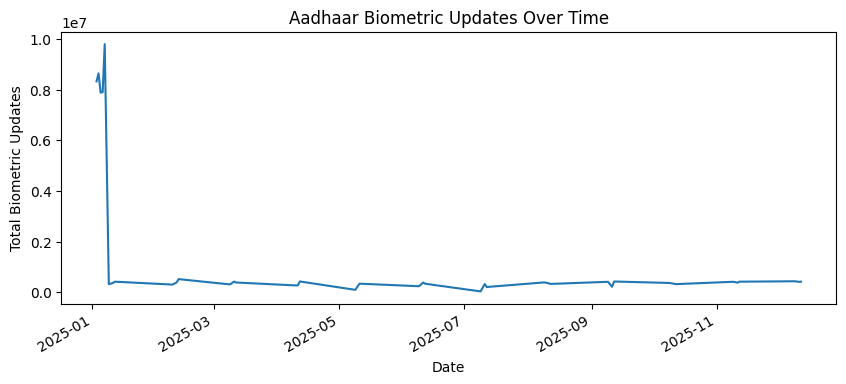

In [5]:
bio_time = biometric_df.groupby("date")["total_biometric_updates"].sum()

plt.figure(figsize=(10,4))
bio_time.plot()
plt.title("Aadhaar Biometric Updates Over Time")
plt.ylabel("Total Biometric Updates")
plt.xlabel("Date")
plt.show()


Persistent biometric update demand indicates ageing and system-refresh requirements beyond initial enrolment.

## Bivariate Analysis:

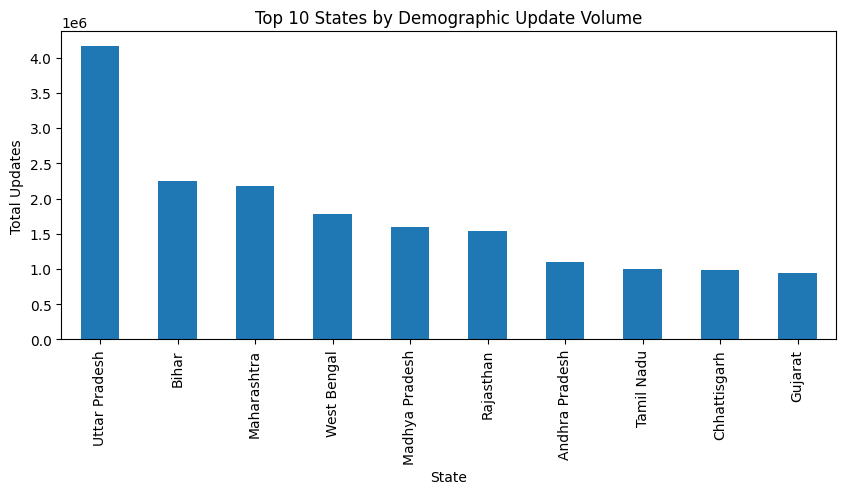

In [7]:
top_states_demo = (
    demographic_df.groupby("state")["total_demographic_updates"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,4))
top_states_demo.plot(kind="bar")
plt.title("Top 10 States by Demographic Update Volume")
plt.ylabel("Total Updates")
plt.xlabel("State")
plt.show()


Update demand is uneven across states, indicating regional differences in mobility and service load.

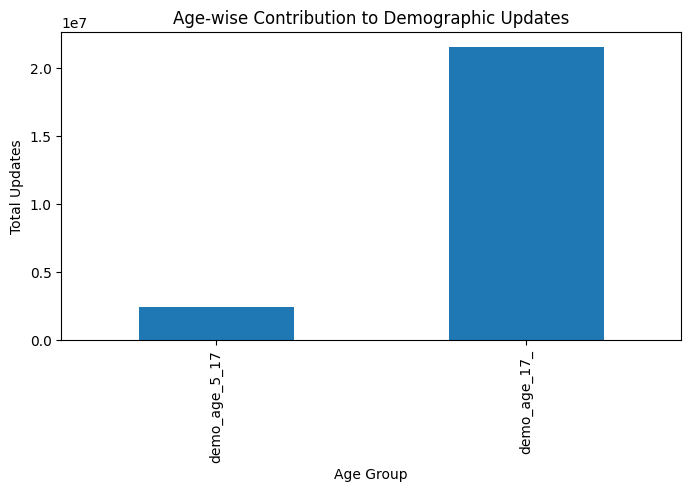

In [8]:
demo_cols = [c for c in demographic_df.columns if c.startswith("demo_age")]
age_contribution = demographic_df[demo_cols].sum()

plt.figure(figsize=(8,4))
age_contribution.plot(kind="bar")
plt.title("Age-wise Contribution to Demographic Updates")
plt.ylabel("Total Updates")
plt.xlabel("Age Group")
plt.show()


Young and working-age populations contribute the highest share of demographic updates, reflecting migration and employment-related changes.

## Trivariate Analysis

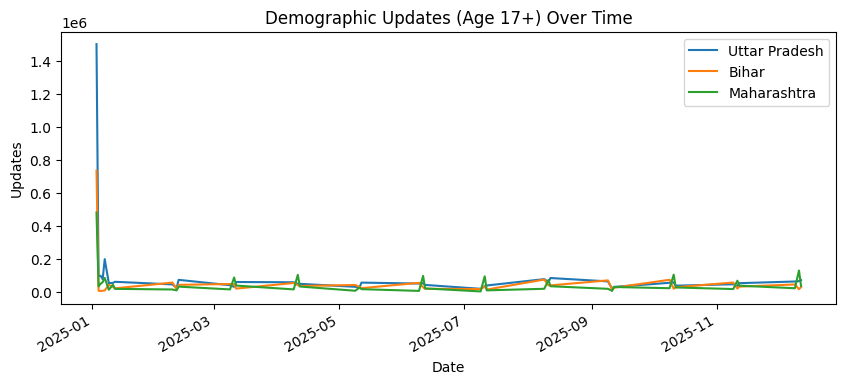

In [35]:
age_col = "demo_age_17_"

top_states = (
    demographic_df.groupby("state")[age_col]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

plt.figure(figsize=(10,4))

for state in top_states:
    temp = demographic_df[demographic_df["state"] == state]
    series = temp.groupby("date")[age_col].sum()
    series.plot(label=state)

plt.title("Demographic Updates (Age 17+) Over Time")
plt.ylabel("Updates")
plt.xlabel("Date")
plt.legend()
plt.savefig("assets/bivariate_trend.png", dpi=300, bbox_inches="tight")
plt.show()


Due to dataset-level age aggregation, the 17+ age group was analyzed as a combined working-age and senior population. Temporal variation in update activity across major states indicates life-event driven Aadhaar updates related to employment, migration, and ageing.

---
## Anomaly Detection: Identifying Operational Stress Signals

**Focus:** District-level biometric update spikes as indicators of operational stress.

Beyond overall trends, it is important to identify abnormal spikes in Aadhaar update activity that may indicate operational stress, infrastructure issues, or targeted update drives.

In this section, district-level biometric update data is analyzed to detect anomalies based on historical baselines. Biometric updates are a strong proxy for system stress, as they are influenced by ageing populations, device performance, and service accessibility.

A simple and explainable statistical approach is used, where an anomaly is defined as a daily update volume significantly exceeding the district’s historical average. This enables early identification of regions requiring administrative attention or resource intervention.



In [32]:
bio_district_daily = (
    biometric_df
    .groupby(["district", "date"])["total_biometric_updates"]
    .sum()
    .reset_index()
)


In [16]:
district_stats = (
    bio_district_daily
    .groupby("district")["total_biometric_updates"]
    .agg(["mean", "std"])
    .reset_index()
)


In [17]:
bio_anomaly_df = bio_district_daily.merge(
    district_stats,
    on="district",
    how="left"
)

bio_anomaly_df["is_anomaly"] = (
    bio_anomaly_df["total_biometric_updates"] >
    (bio_anomaly_df["mean"] + 3 * bio_anomaly_df["std"])
)


In [18]:
anomalies = bio_anomaly_df[bio_anomaly_df["is_anomaly"] == True]
anomalies.head(10)


,district,date,total_biometric_updates,mean,std,is_anomaly
21,Adilabad,2025-01-06,14734,2271.048780,4135.480171,True
22,Adilabad,2025-01-07,17026,2271.048780,4135.480171,True
63,Agar Malwa,2025-01-07,2621,344.750000,719.736303,True
103,Agra,2025-01-07,39762,4446.609756,9744.116306,True
143,Ahmadabad,2025-01-05,2835,281.780488,538.512280,True
186,Ahmadnagar,2025-01-07,43370,6093.121951,10742.930560,True
227,Ahmed Nagar,2025-01-07,511,80.025000,92.437779,True
265,Ahmedabad,2025-01-05,64796,8363.390244,18391.089304,True
267,Ahmedabad,2025-01-07,65705,8363.390244,18391.089304,True
304,Aizawl,2025-01-03,15783,784.073171,2617.689271,True


In [19]:
top_anomaly_districts = (
    anomalies.groupby("district")["total_biometric_updates"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_anomaly_districts


district
Gaurela-pendra-marwahi    3
Nellore                   3
Prakasam                  3
Garhwa *                  3
Chandauli                 3
Gonda                     3
Khordha                   3
Bid                       2
Wanaparthy                2
Warangal                  2
Name: total_biometric_updates, dtype: int64

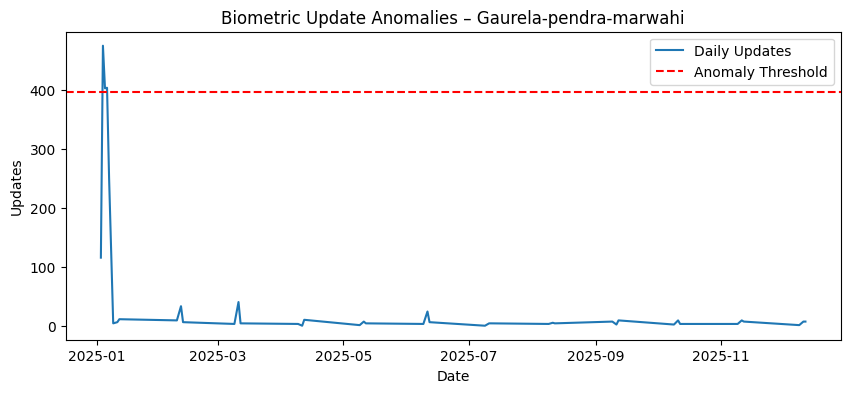

In [36]:
focus_district = top_anomaly_districts.index[0]

temp = bio_anomaly_df[bio_anomaly_df["district"] == focus_district]

plt.figure(figsize=(10,4))
plt.plot(temp["date"], temp["total_biometric_updates"], label="Daily Updates")
plt.axhline(
    temp["mean"].iloc[0] + 3 * temp["std"].iloc[0],
    color="red",
    linestyle="--",
    label="Anomaly Threshold"
)
plt.title(f"Biometric Update Anomalies – {focus_district}")
plt.xlabel("Date")
plt.ylabel("Updates")
plt.legend()
plt.savefig("assets/biometric_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()


District-level biometric update activity shows occasional abnormal spikes exceeding historical baselines. Such anomalies may indicate localized infrastructure stress, device calibration issues, or targeted update drives, highlighting the need for proactive operational monitoring.

---

## Demographic Update Anomalies: Life-Event Driven Demand Surges

**Focus:** Life-event driven demographic update surges at district level.

In addition to biometric stress signals, abnormal spikes in demographic updates can indicate sudden life-event driven demand such as migration, policy changes, or targeted awareness campaigns.

Analyzing demographic update anomalies at the district level helps identify regions experiencing unusual identity update pressure that may require short-term administrative or infrastructural support.


In [21]:
demo_district_daily = (
    demographic_df
    .groupby(["district", "date"])["total_demographic_updates"]
    .sum()
    .reset_index()
)


In [22]:
demo_district_stats = (
    demo_district_daily
    .groupby("district")["total_demographic_updates"]
    .agg(["mean", "std"])
    .reset_index()
)


In [23]:
demo_anomaly_df = demo_district_daily.merge(
    demo_district_stats,
    on="district",
    how="left"
)

demo_anomaly_df["is_anomaly"] = (
    demo_anomaly_df["total_demographic_updates"] >
    (demo_anomaly_df["mean"] + 3 * demo_anomaly_df["std"])
)


In [24]:
demo_anomalies = demo_anomaly_df[demo_anomaly_df["is_anomaly"] == True]
demo_anomalies.head(10)


,district,date,total_demographic_updates,mean,std,is_anomaly
23,Adilabad,2025-01-03,9587,805.825000,1469.884591,True
63,Agar Malwa,2025-01-03,1660,138.000000,300.693898,True
103,Agra,2025-01-03,29890,2234.333333,4698.664079,True
184,Ahmadnagar,2025-01-03,19971,2418.054054,3536.646245,True
257,Ahmedabad,2025-01-03,50947,3408.219512,8074.554661,True
298,Aizawl,2025-01-03,4203,183.810811,680.109094,True
335,Ajmer,2025-01-03,32197,1720.268293,5115.994644,True
376,Akola,2025-01-03,7971,718.947368,1327.312565,True
414,Alappuzha,2025-01-03,1884,360.162162,305.950569,True
451,Aligarh,2025-01-03,34781,2381.205128,5823.413681,True


In [25]:
top_demo_anomaly_districts = (
    demo_anomalies
    .groupby("district")["total_demographic_updates"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_demo_anomaly_districts


district
Gurgaon       3
Nandyal       3
Palwal        3
Panipat       3
Punch         3
Ganderbal     2
Kanker        2
Indore        2
Burhanpur     2
Hoshiarpur    2
Name: total_demographic_updates, dtype: int64

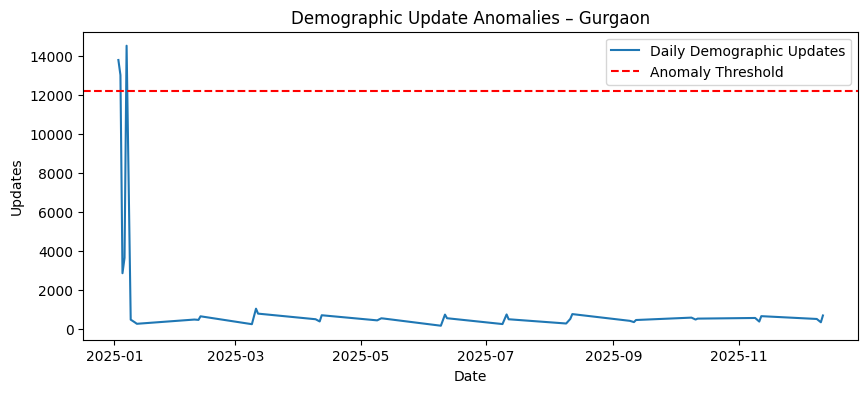

In [38]:
focus_demo_district = top_demo_anomaly_districts.index[0]

temp_demo = demo_anomaly_df[
    demo_anomaly_df["district"] == focus_demo_district
]

plt.figure(figsize=(10,4))
plt.plot(
    temp_demo["date"],
    temp_demo["total_demographic_updates"],
    label="Daily Demographic Updates"
)

plt.axhline(
    temp_demo["mean"].iloc[0] + 3 * temp_demo["std"].iloc[0],
    color="red",
    linestyle="--",
    label="Anomaly Threshold"
)

plt.title(f"Demographic Update Anomalies – {focus_demo_district}")
plt.xlabel("Date")
plt.ylabel("Updates")
plt.legend()
plt.savefig("assets/demographic_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()


District-level demographic update activity shows occasional abnormal surges beyond historical baselines. Such anomalies may reflect sudden migration patterns, targeted update drives, or administrative changes, highlighting the importance of flexible and responsive service provisioning.


---

## Predictive Indicators: Early Warning for Aadhaar Service Demand

While historical analysis explains past trends, proactive governance requires anticipating future service demand.  
In this section, a simple and explainable predictive indicator is developed to forecast short-term Aadhaar update demand.

Rather than complex models, a moving-average based approach is used to identify expected demand levels and flag potential service overload risks. This ensures transparency, interpretability, and operational relevance for decision-makers.


In [27]:
# Aggregate daily total updates
daily_updates = (
    demographic_df.groupby("date")["total_demographic_updates"].sum() +
    biometric_df.groupby("date")["total_biometric_updates"].sum()
).reset_index(name="total_updates")


In [28]:
daily_updates["moving_avg_7"] = (
    daily_updates["total_updates"]
    .rolling(window=7)
    .mean()
)


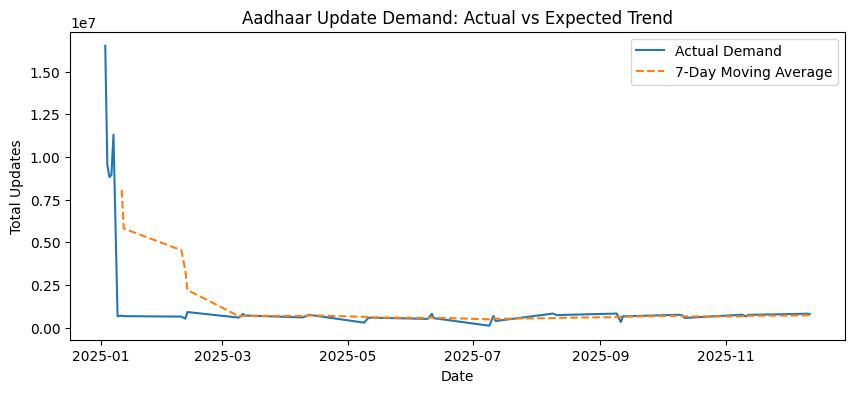

In [39]:
plt.figure(figsize=(10,4))
plt.plot(daily_updates["date"], daily_updates["total_updates"], label="Actual Demand")
plt.plot(daily_updates["date"], daily_updates["moving_avg_7"], 
         linestyle="--", label="7-Day Moving Average")

plt.title("Aadhaar Update Demand: Actual vs Expected Trend")
plt.xlabel("Date")
plt.ylabel("Total Updates")
plt.legend()
plt.savefig("assets/prediction_trend.png", dpi=300, bbox_inches="tight")
plt.show()


In [30]:
daily_updates["high_load_risk"] = (
    daily_updates["total_updates"] >
    1.2 * daily_updates["moving_avg_7"]
)


In [31]:
daily_updates[daily_updates["high_load_risk"] == True].head(10)


,date,total_updates,moving_avg_7,high_load_risk
21,2025-06-11,801599,595000.142857,True
24,2025-07-11,685148,541548.857143,True
26,2025-08-09,820447,551095.142857,True
27,2025-08-11,723960,581779.857143,True
28,2025-08-12,736273,572447.571429,True
29,2025-09-09,820584,611195.571429,True


Short-term demand forecasting using moving averages highlights periods where Aadhaar update activity exceeds expected baselines. Such early warning signals enable proactive staffing, infrastructure scaling, and service readiness before citizen-facing bottlenecks emerge.


---
## Policy Implications & Recommendations

The lifecycle-based analysis of Aadhaar enrolment, demographic updates, biometric refreshes, anomaly detection, and demand forecasting provides several actionable insights for UIDAI. These findings can directly support proactive governance, service optimization, and infrastructure planning.

Based on the analysis, the following recommendations are proposed:


### 1. Shift Operational Focus from Enrolment to Update Services
Regions with low new enrolment but high update activity indicate Aadhaar ecosystem maturity. UIDAI can prioritize strengthening update infrastructure over enrolment expansion in such regions.

### 2. Proactive Resource Allocation Using Anomaly Signals
District-level anomaly detection can be used as an early indicator of operational stress. Districts exhibiting repeated biometric or demographic update spikes should receive temporary staffing reinforcement or mobile update units.

### 3. Senior-Friendly Biometric Update Initiatives
Higher biometric update demand among older populations highlights the need for senior-accessible update mechanisms, including improved biometric capture devices and assisted service centers.

### 4. Seasonal Staffing and Capacity Planning
Temporal spikes in demographic updates suggest predictable life-event driven demand. UIDAI can use these patterns to deploy seasonal staffing and extended service hours during peak periods.

### 5. Early Warning System for Service Load Management
The moving-average based demand forecasting model can serve as a lightweight early warning system, enabling UIDAI to anticipate high service load days and prepare infrastructure in advance.


---
## Conclusion

This project demonstrates how Aadhaar enrolment, demographic updates, and biometric refresh data can be transformed from isolated statistical records into a cohesive lifecycle intelligence system. By applying structured exploratory analysis, district-level anomaly detection, and simple predictive indicators, the analysis moves beyond descriptive reporting toward proactive governance support.

The findings highlight a clear transition from enrolment-driven to update-driven Aadhaar usage, reflecting Aadhaar’s role as a lifelong digital identity. Identified anomalies and early warning signals provide actionable inputs for operational monitoring, infrastructure planning, and service optimization.

Overall, the Aadhaar Lifecycle Intelligence & Maturity Framework (ALIMF) offers a scalable and explainable approach that can assist UIDAI in anticipating service demand, addressing localized stress, and improving citizen experience through data-driven decision-making.
